Step 1- Imports and data loaders

ImageFolder — automatically labels images based on their folder name (real/fake), since we organized them that way in Phase 8 — this is exactly why that folder structure mattered

Normalize(mean=..., std=...) — these specific numbers are the standard ImageNet normalization values; since EfficientNet was originally trained on ImageNet, matching this normalization helps the pretrained weights work correctly on our images

BATCH_SIZE = 16 — kept conservative given your 6GB VRAM; we can increase later if there's headroom, but starting safe avoids an out-of-memory crash mid-training

train_data.classes will print ['fake', 'real'] or ['real', 'fake'] (alphabetical) — important to note which index maps to which class

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

IMG_SIZE = 224
BATCH_SIZE = 16  # kept modest for your 6GB GPU

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

data_dir = "D:/Deepfake-detection/datasets"

train_data = datasets.ImageFolder(f"{data_dir}/train", transform=transform)
val_data = datasets.ImageFolder(f"{data_dir}/validation", transform=transform)
test_data = datasets.ImageFolder(f"{data_dir}/test", transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", train_data.classes)
print("Train size:", len(train_data), "Val size:", len(val_data), "Test size:", len(test_data))

Using device: cuda
Classes: ['fake', 'real']
Train size: 7000 Val size: 1500 Test size: 1500


Step 2 - Load EfficientNet-B0 with pretrained weights, adapt for our 2-class problem

weights=EfficientNet_B0_Weights.DEFAULT — loads weights pretrained on ImageNet (millions of general images) instead of starting from random weights — this is transfer learning: the early layers already know how to detect edges, textures, shapes; we just need to retrain the final decision-making layer for our specific real/fake task

model.classifier[1].in_features — finds out how many features feed into the original final layer (so we match dimensions correctly)

nn.Linear(num_features, 2) — replaces that final layer with a fresh one that outputs exactly 2 values (fake-score, real-score) instead of 1000 ImageNet categories

model.to(device) — moves the entire model onto your GPU

In [2]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Replace the final classifier layer — original EfficientNet outputs 1000 classes (ImageNet),
# we only need 2 (real vs fake)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)

model = model.to(device)
print(model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\ACER/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:04<00:00, 4.60MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


Step 3- Define loss function and optimizer

CrossEntropyLoss — the standard loss function for multi-class (including 2-class) classification problems; it measures how wrong the model's predicted probabilities are compared to the true label

Adam optimizer — an adaptive learning-rate optimizer, generally a safe, reliable default that converges well without much manual tuning

lr=0.0001 — a conservative learning rate appropriate for fine-tuning a pretrained model (much lower than you'd use training from scratch, since we don't want to drastically disturb the already-good pretrained weights)

In [3]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

Step 4- Training loop

model.train() vs model.eval() — switches the model between training mode (updates weights, applies dropout) and evaluation mode (no weight updates, dropout disabled) — critical distinction, a common beginner bug is forgetting this switch

optimizer.zero_grad() → loss.backward() → optimizer.step() — the core training triangle: clear old gradients, compute new ones via backpropagation, update weights

torch.no_grad() during validation — tells PyTorch not to track gradients here, since we're just checking performance, not training — saves memory and speeds things up
We save the model every time validation accuracy improves — this means even if training gets interrupted or overfits in later epochs, you keep the best version, not just whatever the last epoch produced

EPOCHS = 20
Epoch is a hyperparameter (external configuration setting) that defines one complete pass of the entire training dataset through learning algorithm.
Here its 20 means 20 passes complete pass of the entire training, allows model to adjust its parameters (weights and biases) steadily improving predictive accuracy.

In [5]:
import time

EPOCHS = 20
def train_one_epoch():
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate():
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

best_val_acc = 0.0

for epoch in range(EPOCHS):
    start = time.time()
    
    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc = validate()
    
    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
          f"Time: {elapsed:.1f}s")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "D:/Deepfake-detection/saved_models/efficientnet_best.pth")
        print(f"  -> New best model saved (val_acc={val_acc:.4f})")

print("Training complete. Best validation accuracy:", best_val_acc)

Epoch 1/20 | Train Loss: 0.0356, Train Acc: 0.9851 | Val Loss: 0.0597, Val Acc: 0.9713 | Time: 88.2s
  -> New best model saved (val_acc=0.9713)
Epoch 2/20 | Train Loss: 0.0267, Train Acc: 0.9870 | Val Loss: 0.0631, Val Acc: 0.9747 | Time: 86.2s
  -> New best model saved (val_acc=0.9747)
Epoch 3/20 | Train Loss: 0.0317, Train Acc: 0.9873 | Val Loss: 0.0543, Val Acc: 0.9707 | Time: 84.7s
Epoch 4/20 | Train Loss: 0.0199, Train Acc: 0.9919 | Val Loss: 0.0622, Val Acc: 0.9720 | Time: 84.3s
Epoch 5/20 | Train Loss: 0.0256, Train Acc: 0.9920 | Val Loss: 0.0723, Val Acc: 0.9720 | Time: 82.0s
Epoch 6/20 | Train Loss: 0.0242, Train Acc: 0.9904 | Val Loss: 0.0695, Val Acc: 0.9733 | Time: 85.9s
Epoch 7/20 | Train Loss: 0.0166, Train Acc: 0.9924 | Val Loss: 0.0765, Val Acc: 0.9707 | Time: 85.1s
Epoch 8/20 | Train Loss: 0.0159, Train Acc: 0.9929 | Val Loss: 0.0830, Val Acc: 0.9733 | Time: 83.2s
Epoch 9/20 | Train Loss: 0.0176, Train Acc: 0.9931 | Val Loss: 0.0709, Val Acc: 0.9740 | Time: 85.1s
Epoch

Installing libraries for next step

In [7]:
!pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 2.4 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.3 MB 3.1 MB/s eta 0:00:03
   -------- ------------------------------- 1.8/8.3 MB 3.1 MB/s eta 0:00:03
   ------------- -------------------------- 2.9/8.3 MB 3.4 MB/s eta 0:00:02
   ----------------- ---------------------- 3.7/8.3 MB 3.6 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.3 MB 3.8 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.3 MB 4.0 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 4.2 MB/s  0:00:02
Using cached threadpoolctl-3.6.0-py3

Step 5 - Load best model and evaluate on test set

Loads the epoch-12 checkpoint (best validation performance), not the final epoch — matters because it's the actual best-performing version

Runs it on the test set — data the model never saw during training or checkpoint-selection, giving an honest final performance number

classification_report — prints precision, recall, F1-score, and support (count) for each class, plus overall accuracy

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt

model.load_state_dict(torch.load("D:/Deepfake-detection/saved_models/efficientnet_best.pth"))
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=train_data.classes))

Matplotlib is building the font cache; this may take a moment.


              precision    recall  f1-score   support

        fake       0.98      0.98      0.98       750
        real       0.98      0.98      0.98       750

    accuracy                           0.98      1500
   macro avg       0.98      0.98      0.98      1500
weighted avg       0.98      0.98      0.98      1500



Step 6 - Confusion matrix + ROC curve

Confusion matrix — shows exactly how many fake/real images were correctly vs incorrectly classified, as a 2×2 grid (diagonal = correct, off-diagonal = mistakes)

ROC curve — plots true positive rate vs false positive rate across different decision thresholds; AUC (Area Under Curve) close to 1.0 means the model separates the two classes very well regardless of exact threshold chosen

Saves the plot image directly into reports/ — useful for your project report/documentation later

plt.show() displays it inline in the notebook too

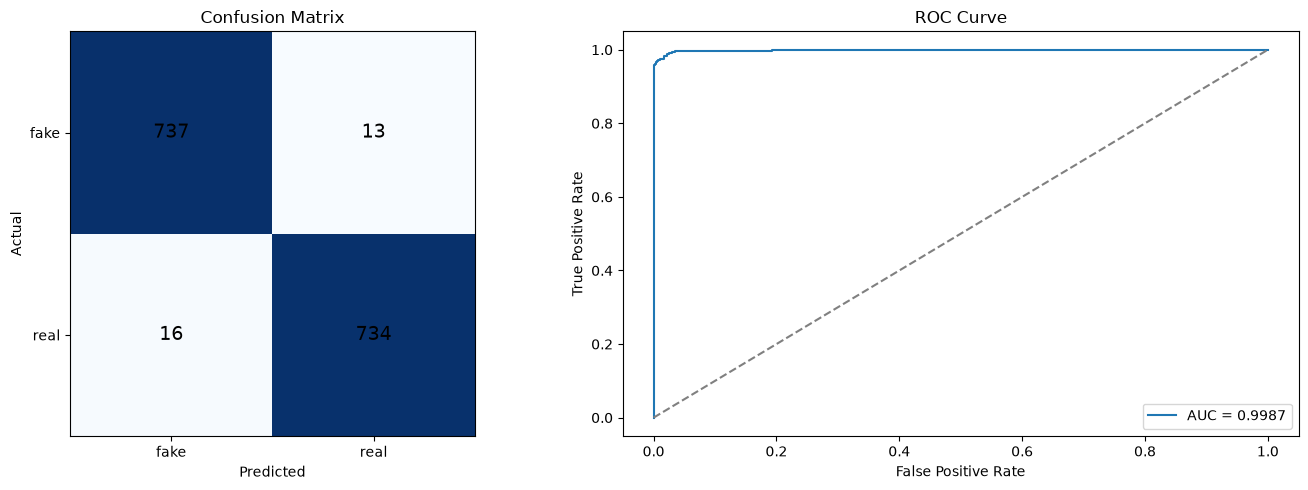

AUC Score: 0.9987


In [9]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(train_data.classes)
axes[0].set_yticklabels(train_data.classes)
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=14)

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc_score = roc_auc_score(all_labels, all_probs)

axes[1].plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig("D:/Deepfake-detection/reports/evaluation_plots.png")
plt.show()

print(f"AUC Score: {auc_score:.4f}")